# Classifier Run Comparison
This notebook visualizes the performance of the Baseline, Synthetic, and Synthetic Filtered classifier runs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv("runs_comparison.csv", index_col=0)
df

,val/auroc,val/auroc_Brocho-pneumonia,val/auroc_Bronchiolitis,val/auroc_Bronchitis,val/auroc_No finding,val/auroc_Other disease,val/auroc_Pneumonia,val/loss,train/loss,best_epoch
Run,,,,,,,,,,
Synthetic Filtered,0.721447,0.735396,0.683983,0.736212,0.726004,0.693021,0.796374,0.965660,0.923862,26
Baseline,0.689654,0.670427,0.696086,0.658511,0.694598,0.662401,0.791326,1.059259,1.073163,5
Synthetic,0.666683,0.678476,0.610484,0.651911,0.688070,0.642186,0.805981,0.944781,1.009600,5


## Overall Performance (Best AUROC)
Comparing the maximum AUROC achieved during training for each run.

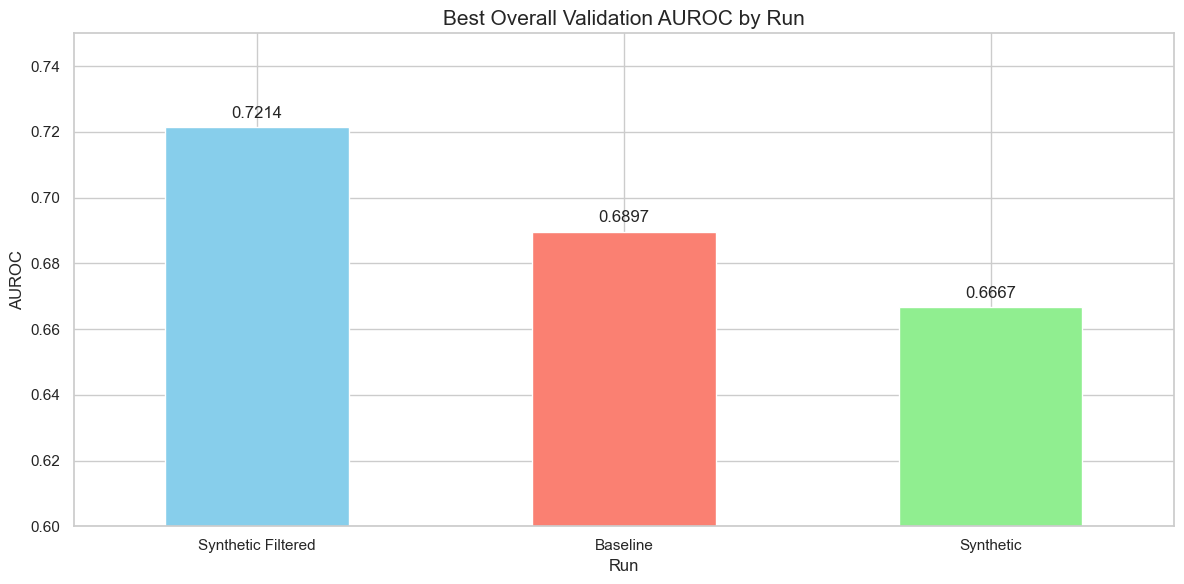

In [3]:
ax = df['val/auroc'].plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Best Overall Validation AUROC by Run', fontsize=15)
plt.ylabel('AUROC', fontsize=12)
plt.ylim(0.6, 0.75)
plt.xticks(rotation=0)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

## Per-Category AUROC Comparison
Breaking down performance by disease category.

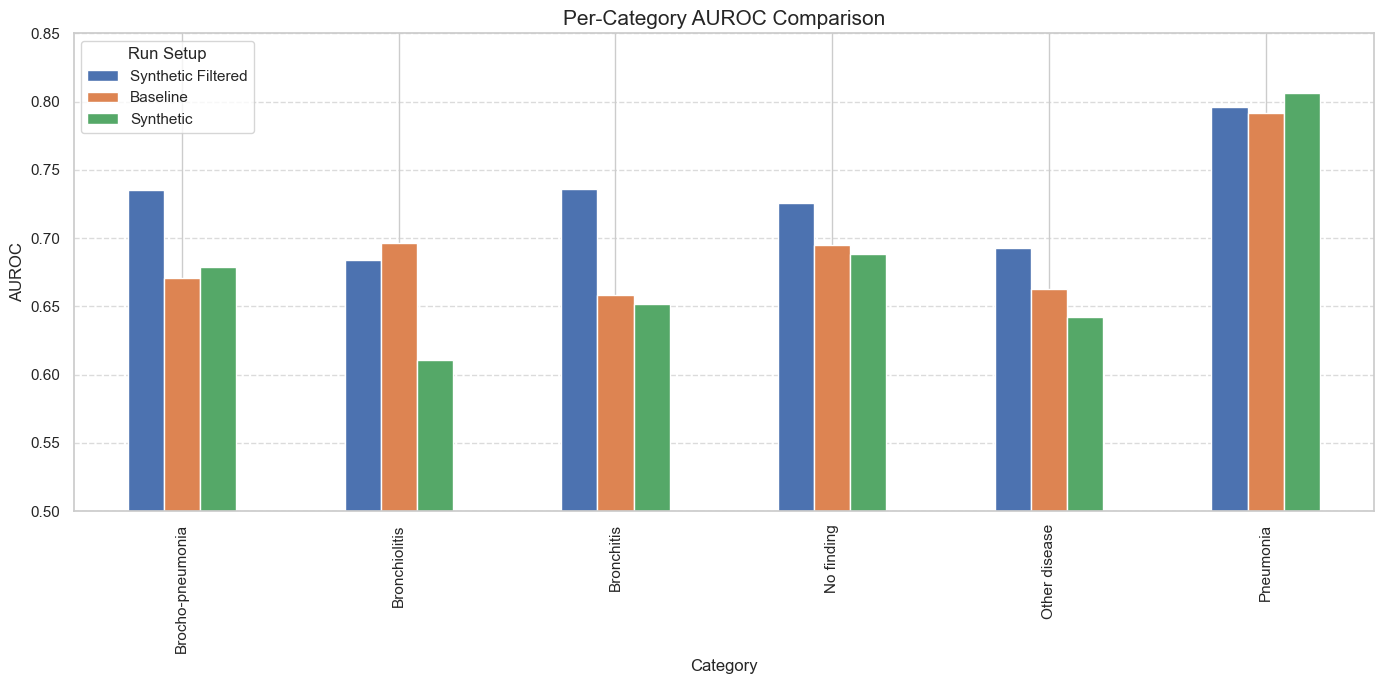

In [4]:
auroc_cols = [c for c in df.columns if 'val/auroc_' in c]
df_categories = df[auroc_cols].copy()
# Clean up column names
df_categories.columns = [c.replace('val/auroc_', '') for c in df_categories.columns]

df_categories.T.plot(kind='bar', figsize=(14, 7))
plt.title('Per-Category AUROC Comparison', fontsize=15)
plt.ylabel('AUROC', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.legend(title='Run Setup')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0.5, 0.85)
plt.tight_layout()
plt.show()

## Best Training/Validation Loss

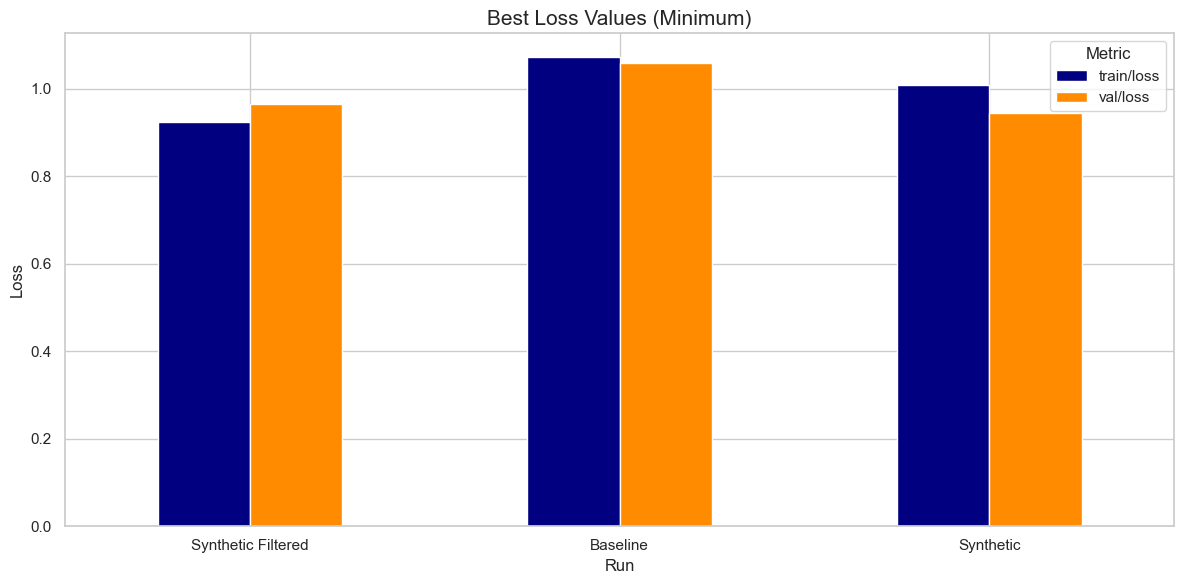

In [5]:
loss_cols = ['train/loss', 'val/loss']
df[loss_cols].plot(kind='bar', color=['navy', 'darkorange'])
plt.title('Best Loss Values (Minimum)', fontsize=15)
plt.ylabel('Loss', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()